In [1]:
import rebound
import numpy as np
from tqdm import tqdm
from scipy import signal
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict


m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [6]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_12 = pham.state.particles[2].a
n12 = pham.state.particles[2].n

alpha12 = 5.6/8.9

sim.move_to_com()

fd_21_k4 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=2, k2=-1, k3=0, k4=-1, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha12)

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=9.19,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_2110 = pham.state.particles[2].a
n2110 = pham.state.particles[2].n

alpha2110 = 5.6/9.19

sim.move_to_com()

fd_21_10 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=21, k2=-11, k3=0, k4=-10, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha2110)

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.62,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_2111 = pham.state.particles[2].a
n2111 = pham.state.particles[2].n

alpha2111 = 5.6/8.62

sim.move_to_com()

fd_21_11 = evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=21, k2=-10, k3=0, k4=-11, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha2111)


sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=9.04,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

'''pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_4120 = pham.state.particles[2].a
n4120 = pham.state.particles[2].n

alpha4120 = 5.6/9.04

sim.move_to_com()

fd_41_20= evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=41, k2=-20, k3=0, k4=-21, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha2111)'''


'pham = PoincareHamiltonian(pvars)\npham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)\npham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)\n\n\na_4120 = pham.state.particles[2].a\nn4120 = pham.state.particles[2].n\n\nalpha4120 = 5.6/9.04\n\nsim.move_to_com()\n\nfd_41_20= evaluate_df_coefficient_dict(\n    df_coefficient_Ctilde(k1=41, k2=-20, k3=0, k4=-21, k5=0, k6=0,\n                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha2111)'

In [9]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat_test_particle = np.zeros(len(times))
sat_p = np.zeros(len(times))
j_p = np.zeros(len(times))
H_energy = np.zeros(len(times))
a_sat_test_particle = np.zeros(len(times))

print(1e7*2*np.pi/sim.particles[2].P)

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_sat_test_particle[i] = sim.particles[2].e
    a_sat_test_particle[i] = sim.particles[2].a
    #sat_p[i] = sim.particles[2].P
    #j_p[i] = sim.particles[1].P
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))


376817.3167445681
Initial Energy: -8.880166071428572e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x7af733815400, [0.0, 0.0, 0.002348194793041187]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [04:55<00:00, 337.93it/s]

Final Energy: -8.880166071436119e-05
Energy Percent Change: 8.497641890705273e-11 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x7af732e3ca50, [0.0, 0.0, 0.002348194793040073]>


In [22]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=9.04,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_4120 = pham.state.particles[2].a
n4120 = pham.state.particles[2].n

alpha4120 = 5.6/9.04

sim.move_to_com()

fd_41_20= evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=41, k2=-20, k3=0, k4=-21, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha4120)


In [25]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.748,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_4121 = pham.state.particles[2].a
n4121 = pham.state.particles[2].n

alpha4121 = 5.6/8.748

sim.move_to_com()

fd_41_21= evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=41, k2=-21, k3=0, k4=-20, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha4121)


In [ ]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.748,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1)


a_4121 = pham.state.particles[2].a
n4121 = pham.state.particles[2].n

alpha4121 = 5.6/8.748

sim.move_to_com()

fd_41_21= evaluate_df_coefficient_dict(
    df_coefficient_Ctilde(k1=41, k2=-21, k3=0, k4=-20, k5=0, k6=0,
                          nu1=0, nu2=0, nu3=0, nu4=0, include_indirect = True), alpha4121)


In [27]:

def c_r(m, n, alpha):
    return m * n * alpha

c_r_21 = c_r(m_jup,n12,alpha12)
c_r_2110 = c_r(m_jup,n2110,alpha2110)
c_r_2111 = c_r(m_jup,n2111,alpha2111)
c_r_4120 = c_r(m_jup,n4120,alpha4120)
c_r_4121 = c_r(m_jup,n4121,alpha4121)



def a_max_21(e, c_r_val, fd, n, a, j2):
    x = (np.abs(c_r_val) / n) * np.abs(fd)
    return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)

def a_max(e, c_r_val, fd, n, a, order):
    return a * np.sqrt((16/3) * (c_r_val/n) * np.abs(fd) * e**order)

/tmp/ipykernel_981/1539828926.py:14: RuntimeWarning: divide by zero encountered in divide
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)
/tmp/ipykernel_981/1539828926.py:14: RuntimeWarning: invalid value encountered in multiply
  return a * (np.sqrt((16/3) * x * e) * np.sqrt(1 + x/(27 * j2**2 * e**3)) - (2/(9 * j2 * e)) * x)


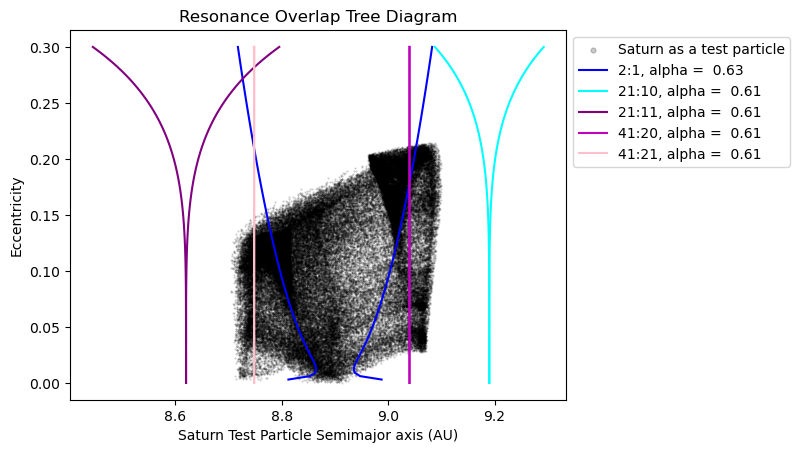

In [28]:
ecc_vals = np.linspace(0,0.3,100)
plt.scatter(a_sat_test_particle, e_sat_test_particle, label="Saturn as a test particle", s=0.25, alpha = 0.2, color = 'black')
plt.plot(8.9 + a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue', label = f'2:1, alpha = {alpha12: .2f}')
plt.plot(8.9 - a_max_21(ecc_vals, c_r_21,fd_21_k4, n12, 8.9,2),ecc_vals, color = 'blue')
plt.plot(9.19 + a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 9.19,11),ecc_vals, color = 'cyan', label = f'21:10, alpha = {alpha2110: .2f}')
plt.plot(9.19 - a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 9.19,11),ecc_vals, color = 'cyan')
plt.plot(8.62 + a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 8.62,10),ecc_vals, color = 'purple', label = f'21:11, alpha = {alpha2110: .2f}')
plt.plot(8.62 - a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 8.62,10),ecc_vals, color = 'purple')
plt.plot(9.04 + a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 9.04,21),ecc_vals, color = 'm', label = f'41:20, alpha = {alpha2110: .2f}')
plt.plot(9.04- a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 9.04,21),ecc_vals, color = 'm')
plt.plot(8.748 + a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 8.748,20),ecc_vals, color = 'pink', label = f'41:21, alpha = {alpha2110: .2f}')
plt.plot(8.748- a_max(ecc_vals, c_r_2110,fd_21_10, n2110, 8.748,20),ecc_vals, color = 'pink')


plt.ylabel('Eccentricity')
plt.xlabel('Saturn Test Particle Semimajor axis (AU)')
plt.title('Resonance Overlap Tree Diagram')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.show()